In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.linalg import ishermitian, eigvals, eigvalsh
from scipy.sparse import kron, eye, diags, csc_matrix, hstack, vstack, random
from scipy.sparse.linalg import expm_multiply, spsolve, norm
from utils import *
from braket.circuits import Circuit

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import SparsePauliOp, Operator
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit import transpile
from qiskit.circuit.library import PauliEvolutionGate
from pytket import OpType
from pytket.passes import RemoveRedundancies, CommuteThroughMultis, RepeatPass, SequencePass, FullPeepholeOptimise, auto_rebase_pass
from pytket.extensions.qiskit import qiskit_to_tk

# Schrodingerization implementation

Lemma.
Let $N = 2^n$ for $n\geq 1$.
Let $H_d = \mathrm{diag}(0,1,\dots,N/2-1,-N/2,-N/2+1,\dots,-1)$. Then $H_d$ can be decomposed as
$$
    H_d = -\frac{1}{2}\left(I - 2^{n} Z_n + \sum_{j=1}^{n} 2^{j-1} Z_j \right).
$$
Proof.

For any computational basis state $\ket{k}$ (the integer $k$ expressed as a binary bit string), let $q_i\in\{0,1\}$ be the value of the $i$-th bit.
Then $k=\sum_{i=1}^{n} 2^{i-1} q_{i}$.
Therefore,
$$
    \bra{k} \sum_{j=1}^{n} 2^{j-1} Z_j \ket{k} = \sum_{j=1}^{n} 2^{j-1} (1 - 2q_j) = 2^{n} - 1 - 2k.
$$
Then
$$
    \bra{k} H_d \ket{k} =
    \begin{cases}
        k &\qquad\text{if $k \leq N/2-1$,}\\
        k-N &\qquad\text{if $k \geq N/2$.}
    \end{cases}
$$

In [60]:
def schrodingerization(A, u_0, N, L, R, T, N_t, lambda_min, r=None):
    dimension = u_0.shape[0]
    h = (R - L) / (N - 1)
    # Convert ODE to PDE
    H1 = (A + np.conj(A).T) / 2
    print("Eigvals of H1:", eigvalsh(H1.toarray()))
    # assert np.alltrue(np.linalg.eigvalsh(H1) <= 0)
    H2 = (A - np.conj(A).T) / 2j
    # print("H1:", H1.toarray())
    # print("H2:", H2.toarray())

    p_vals = np.linspace(L, R, N)
    v_0 = kron(u_0, np.exp(-np.abs(p_vals))).toarray().flatten() # second axis is for p
    # Write out the Hamiltonian
    # centered differences
    H = 1j * (- kron(H1, (1 / (2 * h)) * diags([np.ones(N-1), -np.ones(N-1)], offsets=[1,-1])) + 1j * kron(H2, eye(N)))
    # Solve the PDE
    v = expm_multiply(-1j * H, v_0, start=0, stop=T, num=N_t).real

    # One issue: how to recover the amplitudes? (need to take absolute value?)
    # u_recover = np.sum(np.abs(np.reshape(v, newshape=(N_t, dimension, N))[:,:,N//2:]), axis=2) * h

    u_recover = np.zeros((N_t, dimension))
    for i, t in enumerate(np.linspace(0, T, N_t)):
        a = -lambda_min * t
        a_idx = int((a - L) / h)
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    
    return u_recover

def schrodingerization_ft(A, u_0, N, L, R, T, N_t, lambda_min, r=None):
    dimension = u_0.shape[0]
    h = (R - L) / (N - 1)
    # Convert ODE to PDE
    H1 = (A + np.conj(A).T) / 2
    print("Eigvals of H1:", eigvalsh(H1.toarray()))
    # assert np.alltrue(np.linalg.eigvalsh(H1) <= 0)
    H2 = (A - np.conj(A).T) / 2j
    # print("H1:", H1.toarray())
    # print("H2:", H2.toarray())
    p = np.linspace(L, R, N)
    v_0 = kron(u_0, np.fft.fft(np.exp(-np.abs(p)), norm="ortho")).toarray().flatten() # second axis is for p
    # v_0 = kron(u_0, np.sqrt(2 / np.pi) / (xi ** 2 + 1)).toarray().flatten() # second axis is for p
    # Write out the Hamiltonian
    H = - (kron(H1, -diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L))))) + kron(H2, eye(N)))
    print(H.shape)
    # Solve the PDE
    v = expm_multiply(-1j * H, v_0, start=0, stop=T, num=N_t)
    
    IFFT = np.fft.ifft(np.eye(N), N, norm="ortho")
    v = ((kron(np.eye(dimension), IFFT) @ v.T).real).T
    
    # Issue: how to recover the amplitudes? (need to take absolute value?)
    u_recover = np.zeros((N_t, dimension))
    for i, t in enumerate(np.linspace(0, T, N_t)):
        a = -lambda_min * t
        a_idx = int((a - L) / h)
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    

    return u_recover

def schrodingerization_ft_trot(A, u_0, N, L, R, T, N_t, lambda_min, r):
    assert type(r) == int and r >= 1
    dimension = u_0.shape[0]
    n_p = int(np.log2(N))
    h = (R - L) / (N - 1)
    # Convert ODE to PDE
    H1 = (A + np.conj(A).T) / 2
    print("Eigvals of H1:", eigvalsh(H1.toarray()))
    # assert np.alltrue(np.linalg.eigvalsh(H1) <= 0)
    H2 = (A - np.conj(A).T) / 2j
    # print("H1:", H1.toarray())
    # print("H2:", H2.toarray())
    p = np.linspace(L, R, N)
    v_0 = kron(u_0, np.fft.fft(np.exp(-np.abs(p)), norm="ortho")).toarray().flatten() # second axis is for p
    # v_0 = kron(u_0, np.sqrt(2 / np.pi) / (xi ** 2 + 1)).toarray().flatten() # second axis is for p
    # Write out the Hamiltonian
    H = - (kron(H1, -diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L))))) + kron(H2, eye(N)))
    H1_pauli_list = SparsePauliOp.from_operator(H1.toarray()).to_list()
    xi_pauli_list = SparsePauliOp.from_operator(-diags(np.fft.fftfreq(N, d = 1/(N * 2 * np.pi / (R - L)))).toarray()).to_list()
    H2_pauli_list = SparsePauliOp.from_operator(H2.toarray()).to_list()
    print(xi_pauli_list)

    pauli_list = []
    for i in range(len(H1_pauli_list)):
        for j in range(len(xi_pauli_list)):
            pauli_list.append((H1_pauli_list[i][0] + xi_pauli_list[j][0], -H1_pauli_list[i][1] * xi_pauli_list[j][1]))
    for i in range(len(H2_pauli_list)):
        pauli_list.append((H2_pauli_list[i][0] + ''.join(n_p * ['I']), -H2_pauli_list[i][1]))
    pauli_op = SparsePauliOp.from_list(pauli_list)
    pauli_op_commuting = pauli_op.simplify().group_commuting()
    print(f"Norm of diff: {np.linalg.norm(pauli_op.to_matrix() - H.toarray()) : 0.2f}")

    # Hamiltonian simulation
    t_vals = np.linspace(0, T, N_t)
    v = []
    for t in t_vals:
        v_t = v_0
        dt = t / r
        for _ in range(r):
            for i in range(len(pauli_op_commuting)):
                v_t = expm_multiply(-1j * pauli_op_commuting[i].to_matrix() * dt / 2, v_t)
            for i in range(len(pauli_op_commuting))[::-1]:
                v_t = expm_multiply(-1j * pauli_op_commuting[i].to_matrix() * dt / 2, v_t)
        
        v.append(v_t)
    v = np.array(v)
    # Solve the PDE
    v_no_trot = expm_multiply(-1j * H * T, v_0)
    print(f"Trotter error: {np.linalg.norm(v[-1] - v_no_trot) : 0.2f}")
    # # Fourier transform on xi
    # FT = np.zeros((N,N), dtype=np.complex64)
    # for i in range(N):
    #     for j in range(N):
    #         FT[i,j] = (h / np.sqrt(2 * np.pi)) * np.exp(-1j * xi[i] * p[j])

    # v = ((kron(np.eye(dimension), FT) @ v.T).real).T
    
    IFFT = np.fft.ifft(np.eye(N), N, norm="ortho")
    v = ((kron(np.eye(dimension), IFFT) @ v.T).real).T
    
    # Issue: how to recover the amplitudes? (need to take absolute value?)
    u_recover = np.zeros((N_t, dimension))
    for i, t in enumerate(np.linspace(0, T, N_t)):
        a = -lambda_min * t
        a_idx = int((a - L) / h)
        # u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
        u_recover[i] = np.exp(a) * np.sum(np.reshape(v, newshape=(N_t, dimension, N))[i,:,a_idx:], axis=1) * h
    

    return u_recover


In [61]:
def solve_gradient_flow(A, b, x_0, N, L, R, T, N_t, schrodingerization_method, r=None):
    # The gradient of the optimization problem is Ax-b, so the gradient flow ODE is x'(t) = - Ax + b.
    A_tilde = vstack([hstack([A, -b]), csc_matrix((1, A.shape[0]+1))])
    # print(A_tilde.toarray())
    print("Eigvals of A_tilde: ", eigvals(A_tilde.toarray()))

    lambda_max = np.min(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
    print("Min eval:", lambda_max)
    u_recover = schrodingerization_method(-A_tilde, vstack([x_0, 1]), N, L, R, T, N_t, lambda_min=-norm(b)/2, r=r)
    return u_recover[:,:-1]


In [83]:
def get_xi_pauli_op(n_p, L, R):
    xi_pauli_list = []
    op = n_p * ['I']
    xi_pauli_list.append((''.join(op), 1))

    for i in range(n_p - 1):
        op = n_p * ['I']
        op[n-1-i] = 'Z'
        xi_pauli_list.append((''.join(op), 2 ** i))
    
    op = n_p * ['I']
    op[0] = 'Z'
    xi_pauli_list.append((''.join(op), - 2 ** (n_p - 1)))

    xi_pauli_op = 0.5 * (2 * np.pi / (R - L)) * SparsePauliOp.from_list(xi_pauli_list)
    return xi_pauli_op

State preparation for auxiliary variable

In [84]:
H_1 = 2 * (sum_h_x(n=2, h=np.array([-1, 1])) + sum_h_z(n=2, h=np.array([1, 1])) + 2 * eye(4))
print("H_1:\n", H_1.toarray())
assert H_1[-1,-1] == 0
A = H_1[:3,:3]
print("A:\n", A.toarray())
print(eigvalsh(A.toarray()))
assert np.all(eigvalsh(A.toarray()) > 0)
b = -2 * H_1[:-1,-1]
print("b:\n", b.toarray())
A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
H_2 = (A_tilde - np.conj(A_tilde).T) / 2j

x_0 = csc_matrix(np.array([[0, 0, 0]]).T)
dimension = 3

x_sol = spsolve(A, b)
print("Ground truth:", x_sol)

H_1:
 [[ 8. -2.  2.  0.]
 [-2.  4.  0.  2.]
 [ 2.  0.  4. -2.]
 [ 0.  2. -2.  0.]]
A:
 [[ 8. -2.  2.]
 [-2.  4.  0.]
 [ 2.  0.  4.]]
[2.53589838 4.         9.46410162]
b:
 [[ 0.]
 [-4.]
 [ 4.]]
Ground truth: [-0.66666667 -1.33333333  1.33333333]


In [85]:
L, R = -9,9
# L, R = -4,4
n_p = 6
N_p = 2 ** n_p
h = (R - L) / (N_p - 1)
n_x = int(np.log2(A_tilde.shape[0]))
print("N_p:", N_p)
print(f"Total number of qubits: {n_p + n_x}")
T = 0.8
N_t = 16
r = 2
u_recover = solve_gradient_flow(A, b, x_0, N_p, L, R, T, N_t, schrodingerization)
u_recover_ft = solve_gradient_flow(A, b, x_0, N_p, L, R, T, N_t, schrodingerization_ft)
u_recover_trot = solve_gradient_flow(A, b, x_0, N_p, L, R, T, N_t, schrodingerization_ft_trot, r=r)

print(f"Relative error (Schrodingerization): {np.linalg.norm(u_recover[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
print(f"Relative error (Schrodingerization with FT): {np.linalg.norm(u_recover_ft[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")
print(f"Relative error (Schrodingerization with FT, Trotter): {np.linalg.norm(u_recover_trot[-1,:] - x_sol) / np.linalg.norm(x_sol) : 0.3f}")

N_p: 64
Total number of qubits: 8
Eigvals of A_tilde:  [9.46410162+0.j 2.53589838+0.j 4.        +0.j 0.        +0.j]
Min eval: -1.6568542494923806
Eigvals of H1: [-9.65685425 -4.         -4.          1.65685425]
Eigvals of A_tilde:  [9.46410162+0.j 2.53589838+0.j 4.        +0.j 0.        +0.j]
Min eval: -1.6568542494923806
Eigvals of H1: [-9.65685425 -4.         -4.          1.65685425]
(256, 256)
Eigvals of A_tilde:  [9.46410162+0.j 2.53589838+0.j 4.        +0.j 0.        +0.j]
Min eval: -1.6568542494923806
Eigvals of H1: [-9.65685425 -4.         -4.          1.65685425]
[('IIIIII', (0.17453292519943311+0j)), ('IIIIIZ', (0.1745329251994328+0j)), ('IIIIZI', (0.34906585039886606+0j)), ('IIIZII', (0.6981317007977319+0j)), ('IIZIII', (1.3962634015954638+0j)), ('IZIIII', (2.7925268031909267+0j)), ('ZIIIII', (-5.585053606381855+0j))]
Norm of diff:  0.00
Trotter error:  1.09
Relative error (Schrodingerization):  0.140
Relative error (Schrodingerization with FT):  0.152
Relative error (Schrod

Ground truth

In [86]:
F_gf = lambda t, u: -A.toarray() @ u + b.toarray().reshape(dimension)

t_vals = np.linspace(0, T, N_t)
sol_gf = solve_ivp(F_gf, [0, T], x_0.toarray().reshape(dimension), t_eval=t_vals)

A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
# u_recover = schrodingerization(A_tilde, vstack([x_0, 1]), N, L, R, T, N_t, )

print(eigvals(A_tilde.toarray()))
print(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
F = lambda t, u: A_tilde @ u
t_vals = np.linspace(0, T, N_t)
sol_augmented = solve_ivp(F, [0, T], vstack([x_0, 1]).toarray().reshape(dimension+1), t_eval=t_vals)

[-9.46410162+0.j -2.53589838+0.j -4.        +0.j  0.        +0.j]
[-9.65685425 -4.         -4.          1.65685425]


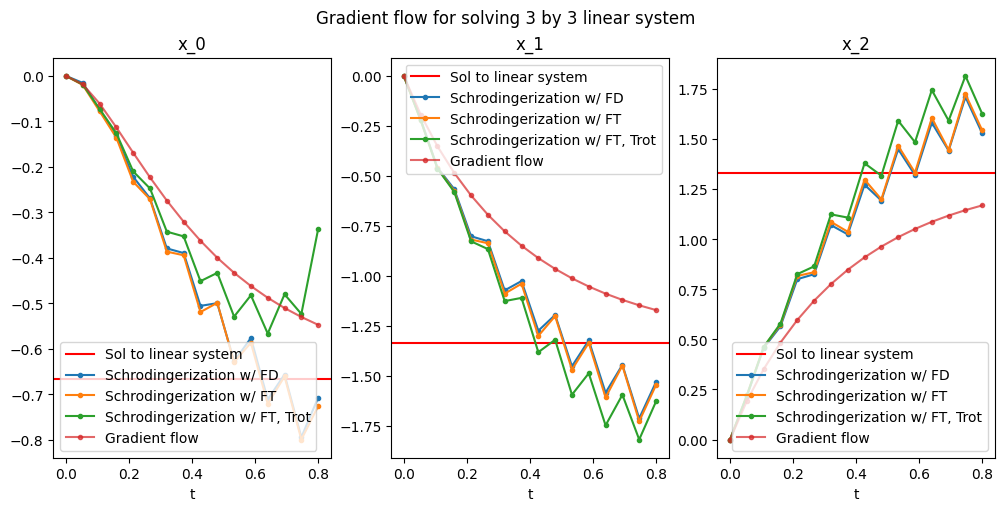

In [87]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(10,5))

aspect = 0.4

for i in range(3):
    
    axs[i].axhline(y=x_sol[i], color='red', label="Sol to linear system")

    axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization w/ FD", markersize=3)
    
    axs[i].plot(t_vals, u_recover_ft[:,i].real, '-o', label="Schrodingerization w/ FT", markersize=3)
    axs[i].plot(t_vals, u_recover_trot[:,i].real, '-o', label="Schrodingerization w/ FT, Trot", markersize=3)
    # axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    
    axs[i].plot(t_vals, sol_gf.y[i], '-o', label="Gradient flow", alpha=0.7, markersize=3)
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
plt.suptitle(f"Gradient flow for solving {dimension} by {dimension} linear system")
plt.show()

In [88]:
xi_vals = np.linspace(L, R, N_p)
amplitude_vector = np.sqrt(2 / np.pi) / (xi_vals ** 2 + 1)
amplitude_vector /= np.linalg.norm(amplitude_vector)

q = QuantumRegister(n_p)
state_prep_circuit = QuantumCircuit(q)
state_prep_circuit.initialize(amplitude_vector, [q[j] for j in range(n_p)])

In [95]:
xi_pauli_list = get_xi_pauli_op(n_p, L, R).to_list()
H_1_pauli_list = SparsePauliOp.from_operator(H_1.toarray()).to_list()
H_2_pauli_list = SparsePauliOp.from_operator(H_2.toarray()).to_list()

pauli_list = []
for i in range(len(H_1_pauli_list)):
    for j in range(len(xi_pauli_list)):
        pauli_list.append((H_1_pauli_list[i][0] + xi_pauli_list[j][0], - H_1_pauli_list[i][1] * xi_pauli_list[j][1]))
for i in range(len(H_2_pauli_list)):
    pauli_list.append((H_2_pauli_list[i][0] + ''.join(n_p * ['I']), H_2_pauli_list[i][1]))

pauli_op = SparsePauliOp.from_list(pauli_list)
# trot_circuit = LieTrotter(reps=r).synthesize(PauliEvolutionGate(pauli_op.group_commuting()))
trot_circuit = SuzukiTrotter(order=2, reps=r).synthesize(PauliEvolutionGate(pauli_op.group_commuting()))

In [96]:
full_circuit = QuantumCircuit(n_p + n_x)
# full_circuit.append(state_prep_circuit, qargs=range(n_p))
# Initial state for x register is [0,0,...,0,1]
for i in np.arange(n_p, n_p + n_x):
    full_circuit.x(i)

full_circuit.append(trot_circuit, qargs=range(n_p+n_x))

In [97]:
compiled_circuit = transpile(full_circuit, basis_gates=['rx', 'ry', 'rz', 'rzx'], optimization_level=3)
print("Depth:", compiled_circuit.depth())
print(compiled_circuit.count_ops())

# tket_circuit = qiskit_to_tk(compiled_circuit)
# gateset = {OpType.Rx, OpType.Ry, OpType.Rz, OpType.XXPhase}
# rebase = auto_rebase_pass(gateset) 
# comp = SequencePass([FullPeepholeOptimise(), CommuteThroughMultis(), RemoveRedundancies(), rebase])
# comp.apply(tket_circuit)
# num_single_qubit_gates, num_two_qubit_gates = tket_circuit.n_1qb_gates(), tket_circuit.n_2qb_gates()
# print(num_single_qubit_gates, num_two_qubit_gates)

Depth: 77
OrderedDict([('rzx', 79), ('rz', 32), ('ry', 22), ('rx', 9)])
